In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [24]:
cmp = pd.read_csv("datasets/computers.csv")
cmp

,Units,Minutes
0,1,23
1,2,29
2,3,49
3,4,64
4,4,74
5,5,87
6,6,96
7,6,97
8,7,109
9,8,119


In [25]:
cmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Units    14 non-null     int64
 1   Minutes  14 non-null     int64
dtypes: int64(2)
memory usage: 356.0 bytes


In [26]:
cmp.describe()

,Units,Minutes
count,14.000000,14.000000
mean,6.000000,97.214286
std,2.961289,46.217177
min,1.000000,23.000000
25%,4.000000,66.500000
50%,6.000000,96.500000
75%,8.750000,138.500000
max,10.000000,166.000000


In [27]:
cmp.describe().corr()

,Units,Minutes
Units,1.000000,0.244757
Minutes,0.244757,1.000000


In [28]:
mean_value = cmp['Minutes'].mean()
print(mean_value)

97.21428571428571


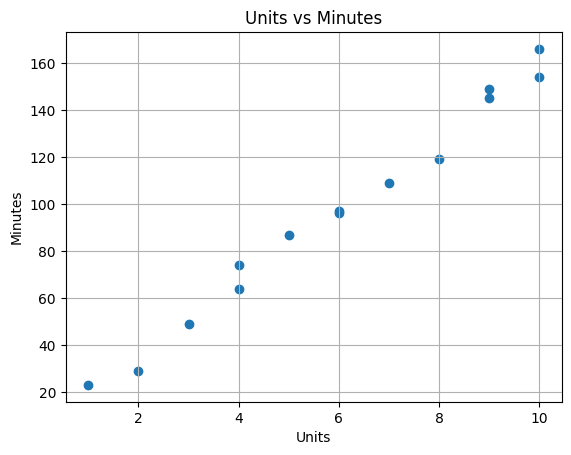

In [29]:
plt.scatter(cmp['Units'],cmp['Minutes'],colorizer='blue',marker='o')
plt.grid()
plt.title("Units vs Minutes")
plt.xlabel("Units")
plt.ylabel("Minutes")
plt.show()

Create a model

In [30]:
Model0 = cmp['Minutes'].mean()
Model1 = 10 + 12 * cmp['Units']
Model2 = 6 + 18 * cmp['Units']

In [ ]:
cmp['Model0'] = Model0
cmp['Model1'] = Model1
cmp['Model2'] = Model2

In [32]:
cmp.head()

,Units,Minutes,Model0,Model1,Model2
0,1,23,97.214286,22,24
1,2,29,97.214286,34,42
2,3,49,97.214286,46,60
3,4,64,97.214286,58,78
4,4,74,97.214286,58,78


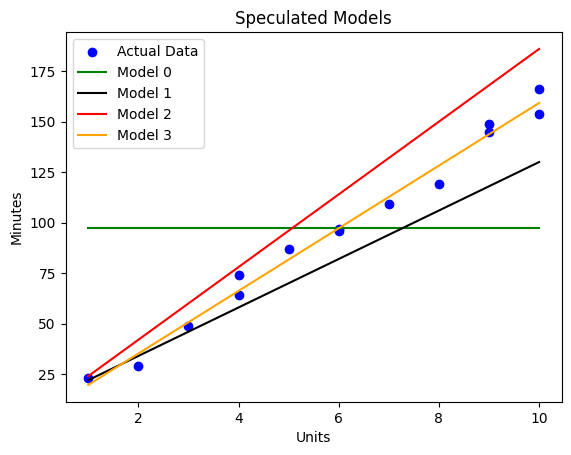

In [39]:
fig,ax = plt.subplots()
ax.scatter(cmp['Units'],cmp['Minutes'],color='blue',marker='o',label='Actual Data')
ax.plot(cmp['Units'],cmp['Model0'],color='green',label='Model 0')
ax.plot(cmp['Units'],cmp['Model1'],color='black',label='Model 1')
ax.plot(cmp['Units'],cmp['Model2'],color='red',label='Model 2')
ax.plot(cmp['Units'],cmp['Model3'],color='orange',label='Model 3')
ax.set_xlabel("Units")
ax.set_ylabel("Minutes")
ax.set_title("Speculated Models")
ax.legend()

# Build a scikit-learn model  
## Linear Regression

In [34]:
X = cmp[['Units'] ]
y = cmp['Minutes']
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)
print(model.intercept_)
print(model.coef_)

4.161654135338296
[15.50877193]


In [37]:
model3 = model.intercept_ + model.coef_ * cmp['Units']

In [38]:
cmp['Model3'] = model3
cmp

,Units,Minutes,Model0,Model1,Model2,Model3
0,1,23,97.214286,22,24,19.670426
1,2,29,97.214286,34,42,35.179198
2,3,49,97.214286,46,60,50.687970
3,4,64,97.214286,58,78,66.196742
4,4,74,97.214286,58,78,66.196742
5,5,87,97.214286,70,96,81.705514
6,6,96,97.214286,82,114,97.214286
7,6,97,97.214286,82,114,97.214286
8,7,109,97.214286,94,132,112.723058
9,8,119,97.214286,106,150,128.231830


In [45]:
rsq = model.score(X,y)
print(f"{rsq*100}%")

98.74371980620737%


# Exercise 2: Multiple Linear Regression Model

In [50]:
student_marks = pd.read_csv("datasets/std_marks_data.csv")
student_marks.head()

,hours,age,internet,marks
0,6.84,15,0,78.64
1,6.56,20,1,88.80
2,NaN,21,1,88.90
3,8.67,22,1,98.99
4,7.55,17,1,92.34


In [51]:
student_marks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   hours     288 non-null    float64
 1   age       300 non-null    int64  
 2   internet  300 non-null    int64  
 3   marks     300 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 9.5 KB


In [53]:
student_marks.describe()

,hours,age,internet,marks
count,288.000000,300.000000,300.000000,300.000000
mean,5.494514,20.210000,0.550000,73.235467
std,2.590130,3.396718,0.498325,16.630650
min,0.000000,15.000000,0.000000,43.450000
25%,3.850000,17.000000,0.000000,55.900000
50%,6.200000,21.000000,1.000000,77.740000
75%,7.440000,24.000000,1.000000,88.800000
max,9.990000,25.000000,1.000000,99.990000


In [54]:
student_marks.isna().sum()

hours       12
age          0
internet     0
marks        0
dtype: int64

In [58]:
student_marks['hours'].unique()

array([6.84, 6.56,  nan, 8.67, 7.55, 8.8 , 8.76, 7.44, 1.23, 4.24, 3.85,
       6.4 , 4.  , 6.8 , 6.2 , 1.7 , 0.5 , 5.34, 5.67, 4.8 , 2.99, 6.55,
       9.33, 4.44, 2.22, 1.11, 8.01, 9.99, 3.  , 0.  , 9.9 , 3.4 ])

In [62]:
student_marks.hours.fillna(student_marks.hours.mean(),inplace=True)

C:\Users\JEN1L\AppData\Local\Temp\ipykernel_2592\2177554811.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  student_marks.hours.fillna(student_marks.hours.mean(),inplace=True)


In [63]:
student_marks.isna().sum()

hours       0
age         0
internet    0
marks       0
dtype: int64

In [73]:
X = student_marks.loc[:,['hours','age','internet']]
# X = student_marks.iloc[:,:-1]
X

,hours,age,internet
0,6.840000,15,0
1,6.560000,20,1
2,5.494514,21,1
3,8.670000,22,1
4,7.550000,17,1
...,...,...,...
295,2.990000,25,0
296,6.550000,15,1
297,0.000000,20,1
298,9.900000,22,0


In [74]:
y = student_marks['marks']
y

0      78.64
1      88.80
2      88.90
3      98.99
4      92.34
       ...  
295    43.45
296    77.74
297    75.76
298    99.99
299    99.99
Name: marks, Length: 300, dtype: float64

In [87]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

In [90]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(240, 3) (60, 3) (240,) (60,)


In [92]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)
print(model.intercept_, model.coef_)

57.370834531596486 [1.39737824 0.32221317 3.07863699]


In [94]:
model1 = model.intercept_ + model.coef_[0]*X['hours'] + model.coef_[1]*X['age'] + model.coef_[2]*X['internet']
student_marks['predicted_marks'] = model1
student_marks

,hours,age,internet,marks,predicted_marks
0,6.840000,15,0,78.64,71.762099
1,6.560000,20,1,88.80,76.060536
2,5.494514,21,1,88.90,74.893862
3,8.670000,22,1,98.99,79.653431
4,7.550000,17,1,92.34,76.477301
...,...,...,...,...,...
295,2.990000,25,0,43.45,69.604325
296,6.550000,15,1,77.74,74.435497
297,0.000000,20,1,75.76,66.893735
298,9.900000,22,0,99.99,78.293569


In [98]:
hours = int(input("Enter number of hours studied: "))
age = int(input("Enter age of student: "))
internet = int(input("Enter 1 if student has internet access else enter 0: "))
data = [[hours,age,internet]]
print(f"Predicted Marks: {model.predict(data)[0]}")

Predicted Marks: 67.2159481316259


d:\WORK\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Exercise 3: Build Logistic Regression Model

In [100]:
chd = pd.read_csv("datasets/chd_data.csv")
chd.head()

,age,chd
0,20,0
1,23,0
2,24,0
3,25,1
4,25,0


In [102]:
chd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     100 non-null    int64
 1   chd     100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB


In [103]:
chd.describe()

,age,chd
count,100.000000,100.00000
mean,44.380000,0.43000
std,11.721327,0.49757
min,20.000000,0.00000
25%,34.750000,0.00000
50%,44.000000,0.00000
75%,55.000000,1.00000
max,69.000000,1.00000


In [104]:
chd.isna().sum()

age    0
chd    0
dtype: int64

In [105]:
chd['chd'].unique()

array([0, 1])

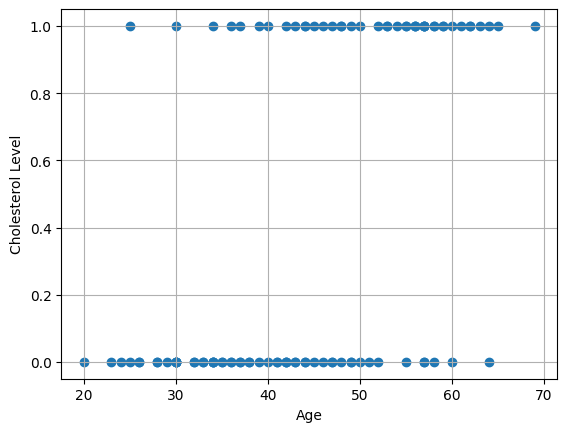

In [111]:
plt.scatter(chd['age'], chd['chd'])
plt.xlabel("Age")
plt.ylabel("Cholesterol Level")
plt.grid()

In [137]:
X = chd[['age']]
y = chd['chd']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7)

In [138]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [139]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(70, 1) (70,) (30, 1) (30,)


In [140]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [141]:
print(model.intercept_, model.coef_)

[-4.65212778] [[0.09780218]]


In [142]:
data = [[int(input("Enter age: "))]]
print("Predicted target i.e. 'chd' value:", model.predict(data)[0])

Predicted target i.e. 'chd' value: 0


d:\WORK\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [143]:
print(f"Accuracy of model in training data {model.score(X_train, y_train)}\nAccuracy of model in testing data {model.score(X_test, y_test)}")


Accuracy of model in training data 0.7428571428571429
Accuracy of model in testing data 0.7333333333333333
